In [55]:
import matplotlib.pyplot as plt
from scipy import signal
from scipy.io import wavfile
import numpy as np
import textgrid
import librosa
import librosa.display

from pathlib import Path
import re

In [96]:
plot_word = "bountiful"
plot_files = list(Path("textgrids").glob(f"*_{plot_word}_*.TextGrid"))

plot_max_frequency = 8000

In [ ]:
step_files = {}
for f in plot_files:
    stimulus_step = int(re.findall(r"_(\d+)$", f.stem)[0])
    step_files[stimulus_step] = f
steps = sorted(step_files.keys())

2_bountiful_bm_001
2_bountiful_bm_002
2_bountiful_bm_003
2_bountiful_bm_004
2_bountiful_bm_005
2_bountiful_bm_006


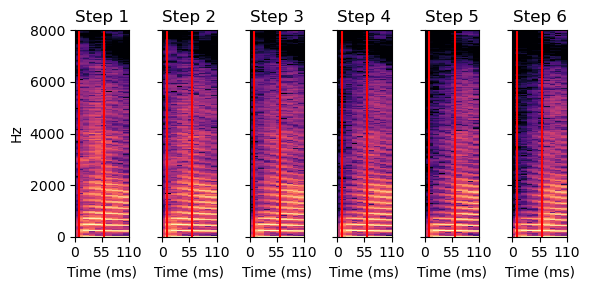

In [105]:
n_cols = 6
n_rows = int(np.ceil(len(steps) / n_cols))

fig, axs = plt.subplots(n_rows, n_cols, figsize=(1 * n_cols, 3 * n_rows), sharey=True)

interval = None

for i, (ax, step) in enumerate(zip(axs.flat, steps)):
    f = step_files[step]
    wav_path = f.with_suffix(".wav")
    audio_data, sample_rate = librosa.load(wav_path, sr=None, mono=True)

    ax.set_title(f"Step {step}")

    print(f.stem)
    stimulus_step = int(re.findall(r"_(\d+)$", f.stem)[0])

    # HACK only do this once so that it's consistent across files
    if interval is None:
        tg = textgrid.TextGrid.fromFile(f)
        tier = next(tier for tier in tg.tiers if tier.name == "phonemes")
        interval = next(interval for interval in tier.intervals if interval.mark.strip() != "")

    # STFT -> power -> dB
    hop_length = 512
    n_fft = 2048
    S = librosa.stft(audio_data, n_fft=n_fft, hop_length=hop_length)
    S = np.abs(S) ** 2
    # S = librosa.feature.melspectrogram(y=audio_data,
    #                                    sr=sample_rate,
    #                                    n_fft=n_fft,
    #                                    hop_length=hop_length,
    #                                    n_mels=80)
    S = librosa.power_to_db(S, ref=np.max)

    librosa.display.specshow(S, sr=sample_rate, n_fft=n_fft, hop_length=hop_length,
                             x_axis="time", y_axis="linear", ax=ax)

    
    ax.set_ylim((0, plot_max_frequency))
    if i > 0:
        ax.set_ylabel(None)

    times = librosa.times_like(S, sr=sample_rate, hop_length=hop_length)

    # plot this much left-right time padding around the focus interval
    plot_padding = 0.05
    ax.set_xlim((max(0, interval.minTime - plot_padding), min(times[-1], interval.maxTime + plot_padding)))

    xticks = np.linspace(ax.get_xlim()[0], ax.get_xlim()[1], 3, endpoint=True)
    ax.set_xticks(xticks)
    ax.set_xticklabels(["%d" % x for x in np.array(xticks) * 1000])
    ax.set_xlabel("Time (ms)")

    ax.axvline(interval.minTime, color='r')
    ax.axvline(interval.maxTime, color='r')

fig.tight_layout()

# axs.flat[0].set_title("/b/")
# axs.flat[-1].set_title("/m/")

In [88]:
interval

Interval(0.00875, 0.06507, b)

In [65]:
S.shape

(513, 100)

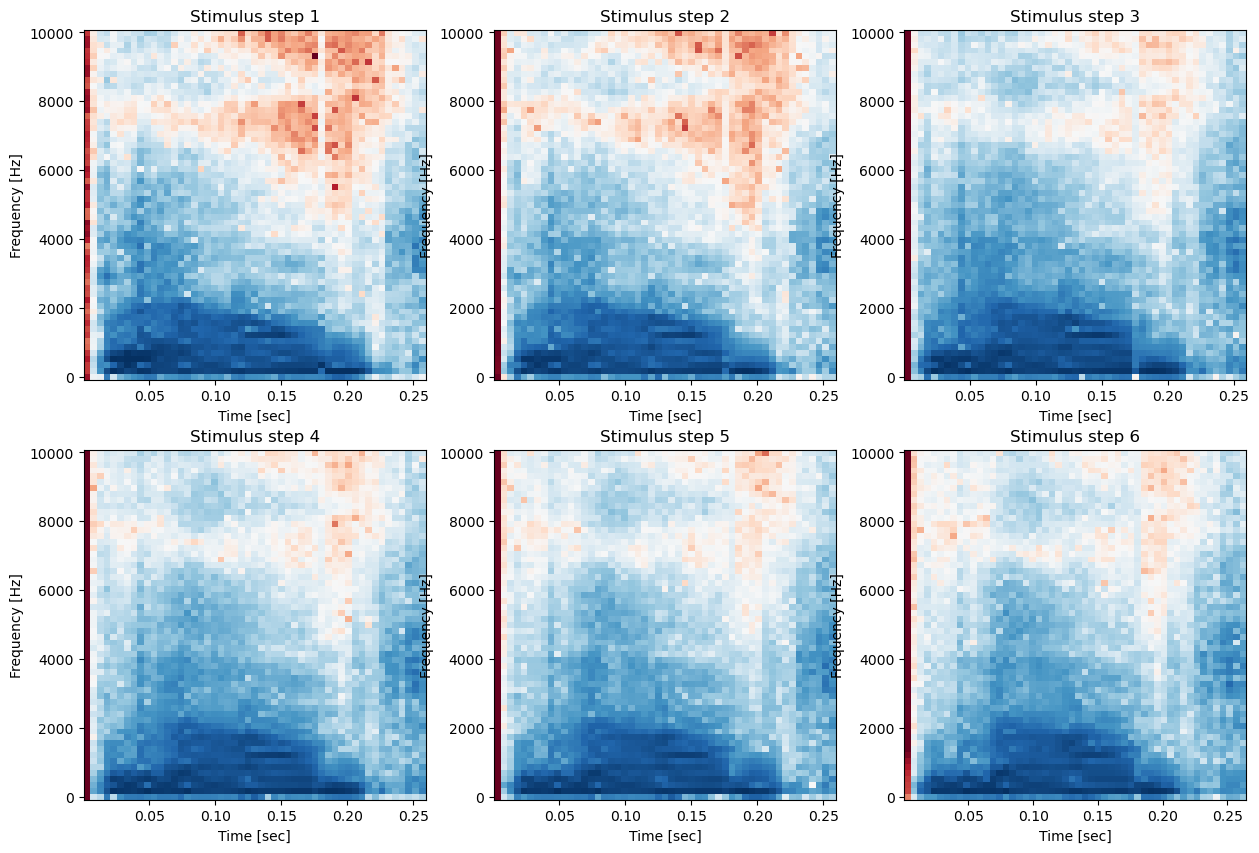

In [54]:
n_cols = 3
n_rows = int(np.ceil(len(specs) / n_cols))

f, axs = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 5 * n_rows))

steps = sorted(specs.keys())
for ax, step in zip(axs.flat, steps):
    freqs, times, spectrogram_data = specs[step]
    ax.pcolormesh(times, freqs, np.log(spectrogram_data + 1e-10), cmap="RdBu")
    ax.set_title(f"Stimulus step {step}")
    ax.set_ylabel("Frequency [Hz]")
    ax.set_xlabel("Time [sec]")
    # ax.set_ylim(0, 8000)

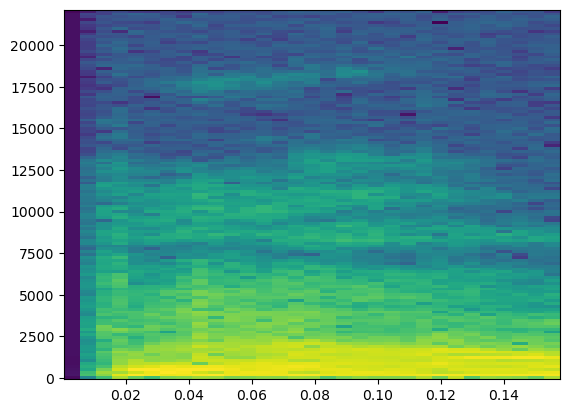

In [35]:
plt.pcolormesh(times, freqs, np.log(spectrogram_data))